<img src="./src/LogoUTNNegro.png" align="right" width="150">

#### Teoría de los Circuitos 2

# Trabajo Semanal 4
#### Renzo Villani

### Consignas

A partir de la siguiente plantilla, sabiendo que en banda de paso la respuesta es *Chebyshev*:

<center><img src="./src/img1_TS4.png"></center>

- $f_0 = 22kHz; F_{s1}=17kHz; f_{s2}=36kHz$;
- $Q=5$ siendo $\omega1.\omega2=\omega_0² \space\space\space\space\space \omega2-\omega1 = \omega_0/Q$

1. Obtener la plantilla de atenuación normalizada en frecuencia.  Indicar los valores de $\alpha_{max}$ y de $\alpha_{min}$
2.  Obtener la función transferencia *normalizada* del prototipo pasa bajo que satisfaga el requerimiento del filtro pasa banda.
3.  Aplicar el núcleo de transformación *pasa banda* y obtener la transferencia. Factorizar convenientemente para expresar en *SOS*.
4.  Realizar la simulación numérica en python. Graficar la respuesta en frecuencia del filtro pasa banda total, y las de las SOS. 

**Bonus**

+10 💎 Simulación Circuital del filtro *pasa banda* implementado mediante secciones pasivas separadas por seguidores de tensión activos. 

+10 💎 Dado el *pasa bajo* hallado en 2)  aplicar el núcleo de transformación *pasa altos* y obtener la transferencia.

+10 💎 Dado el *pasa bajo* hallado en 2) , implementarlo con pasivos y aplicar la transformación de Bruton. Obtener el valor numérico de **D** del ***FDNR*** siendo $Z_{FDNR}=\frac{1}{s²D}$

### Punto 1

Obtengo la plantilla de atenuación normalizando en frecuencia e invirtiendo la plantilla dada. Recordar que en $\alpha = \frac{1}{|T|}$ y está en escala de dB.

<center><img src="./src/img2_TS4.png"  width="800"></center>

- $\alpha_{min}=0,5dB$
- $\alpha_{max1}=16dB$
- $\alpha_{max2}=24dB$

### Punto 2

El siguiente paso del diseño es obtener la transferencia normalizada del *filtro pasa bajo prototipo* para esta plantilla de pasabanda.

Para ello se tiene que iterar el cálculo de $\alpha_{min}$ en ambos "cruces de la banda" para calcular el orden mínimo que satisfaga cada caso. Luego, de estos dos órdenes se toma al mayor ya que representa un comportamiento más restringido. **Si puede cumplir la condición más ajustada, podrá con la más olgada fácilmente**.

<center><img src="./src/img3_TS4.png"  width="800"></center>

Obtengo la pantilla pasabajos y con el 3er polinomio de Cheby calculo la transferencia.

<center><img src="./src/img4_TS4.png"  width="800"></center>

Continué vía código y expresé la transferencia cómo secciones de segundo orden.

In [6]:
# Importo las librerías para trabajar de acá en adelante.

# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
from scipy import signal as sig
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, analyze_sys, tf2sos_analog

from pytc2.general import a_equal_b_latex_s, print_latex

[-0.31322824+1.02192749j -0.31322824-1.02192749j -0.62645649+0.j        ]


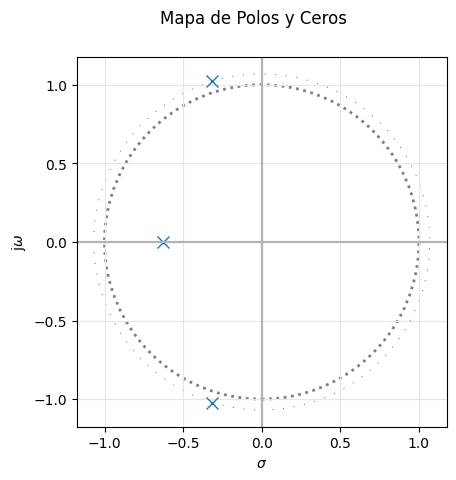

In [7]:
alfMax = 0.5

order = 3

# Para obtener la función transferencia del Cheby vía código directamente
# z,p,k = sig.cheb1ap(order, alfMax)
# num, den = sig.zpk2tf(z,p,k)

# Pero esta vez lo voy a hacer de forma manual

eps = np.sqrt( 10**(alfMax/10) - 1 )   # 0.34931140018894796

# Construyo |T|²
numsq = np.sqrt(1/16/ eps**2)
den = np.array([1, 0, 3/2, 0 , 9/16, 0 , -1/16/ eps**2])
Tsq = TransferFunction(numsq, den)   

# Contruyo la transferencia Cheby
num = np.sqrt(1/16/ eps**2)
roots = np.roots(den)
roots = roots[ np.real(roots) < 0 ]   # filtro los polos del semiplano derecho
den = np.poly(roots)
T = TransferFunction(num, den)

pzmap(T)
print(roots)

In [8]:
poles1 = np.array([
    -0.31322824+1.02192749j,
    -0.31322824-1.02192749j
])

poles2 = np.array([
    -0.62645649+0.j
])

zeros = []

num1, den1 = sig.zpk2tf(zeros, poles1, 1)
num2, den2 = sig.zpk2tf(zeros, poles2, 1)

# Fijo los numeradores para 0dB
num1 = den1[2]
num2 = den2[1]

# Contruyo las expresiones
s = sp.symbols("s");

num1_expr = num1
den1_expr = s**2 + s*den1[1] + den1[2]
num2_expr = num2
den2_expr = s + den2[1]

T1_expr = num1_expr / den1_expr
T2_expr = num2_expr / den2_expr

print_latex(a_equal_b_latex_s('T1(s)', T1_expr))
print_latex(a_equal_b_latex_s('T2(s)', T2_expr))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Punto 3

Aplico el núcleo de transformación:

[-0.03450874+1.10691778j -0.03450874-1.10691778j -0.06264565+0.99803583j
 -0.06264565-0.99803583j -0.02813691+0.90253228j -0.02813691-0.90253228j]


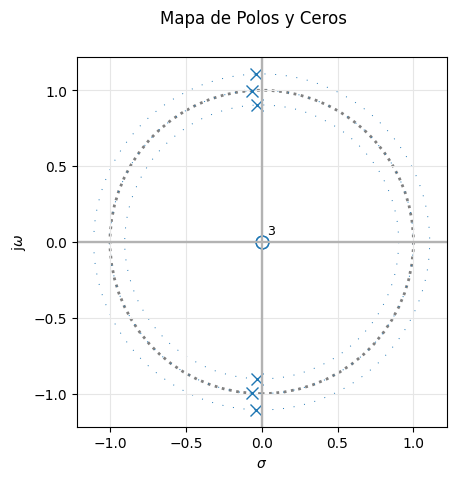

In [9]:
wo = 1
bw = 0.2

num, den = sig.lp2bp(num, den, wo, bw)
T = TransferFunction(num, den)

K = num[3]

roots = np.roots(den)

pzmap(T)

print(roots)

Notar como la transformación **duplica el orden del filtro**.

Expreso la transferencia, tanto como un cociente de polinomios como por secciones de segundo orden.

In [10]:
poles0 = np.array([
    -0.06264565+0.99803583j,
    -0.06264565-0.99803583j
])

poles1 = np.array([
    -0.02813691+0.90253228j,
    -0.02813691-0.90253228j
])

poles2 = np.array([
    -0.03450874+1.10691778j,
    -0.03450874-1.10691778j
])

num0, den0 = sig.zpk2tf(zeros, poles0, 1)
num1, den1 = sig.zpk2tf(zeros, poles1, 1)
num2, den2 = sig.zpk2tf(zeros, poles2, 1)

# Fijo los numeradores para 0dB
num0 = den0[1]
num1 = den1[1]
num2 = den2[1]

T2 = TransferFunction(num2, den2)
T0 = TransferFunction(num0, den0)
T1 = TransferFunction(num1, den1)

# Contruyo las expresiones
s = sp.symbols("s");

num_expr = num[0]*s**3
den_expr = s**6 + den[1]*s**5 + den[2]*s**4 + den[3]*s**3 + den[4]*s**2 + s*den[5] + den[6]

num0_expr = s*den0[1]
den0_expr = s**2 + s*den0[1] + den0[2]

num1_expr = s*den1[1]
den1_expr = s**2 + s*den1[1] + den1[2]

num2_expr = s*den2[1]
den2_expr = s**2 + s*den2[1] + den2[2]

T_expr = num_expr / den_expr
T0_expr = num0_expr / den0_expr
T1_expr = num1_expr / den1_expr
T2_expr = num2_expr / den2_expr

print_latex(a_equal_b_latex_s('T(s)', T_expr))
print_latex(a_equal_b_latex_s('T0(s)', T0_expr))
print_latex(a_equal_b_latex_s('T1(s)', T1_expr))
print_latex(a_equal_b_latex_s('T2(s)', T2_expr))

#([0.00572555, 0.        , 0.        , 0.        ]),
#array([1.        , 0.25058259, 3.06139582, 0.50689074, 3.06139582,0.25058259, 1.        ]),

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Punto 4

Grafico matemáticamente el filtro y a cada etapa por separado.

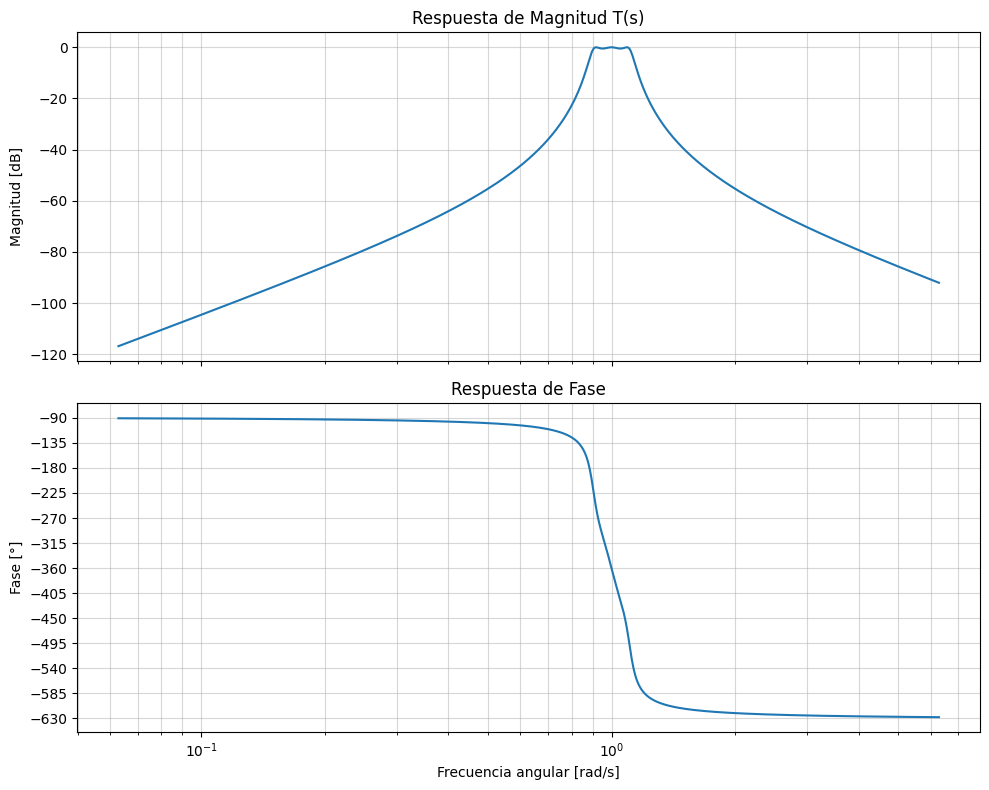

In [11]:
f = np.logspace(-2, 0, 1000)

w = 2*np.pi*f

w, mag, phase = sig.bode(T,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

attenuation_db = -mag

# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud T(s)')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-630, -89, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

ax_phase.set_xlabel('Frecuencia angular [rad/s]')


plt.tight_layout()
plt.show()

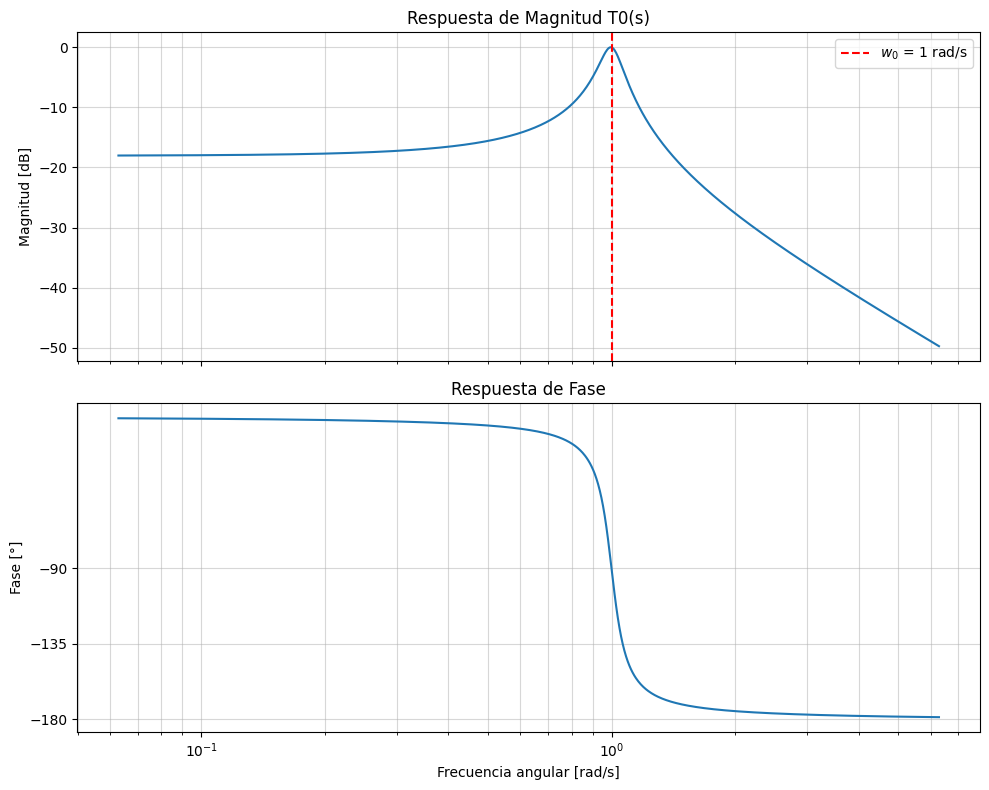

In [17]:
w, mag, phase = sig.bode(T0,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

attenuation_db = -mag

# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud T0(s)')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)
ax_mag.axvline(1, color='red', linestyle='--', label=f'$w_0$ = {1} rad/s')
ax_mag.legend()

# Gráfico de Fase
ticks = np.arange(-630, -89, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

ax_phase.set_xlabel('Frecuencia angular [rad/s]')

plt.tight_layout()
plt.show()

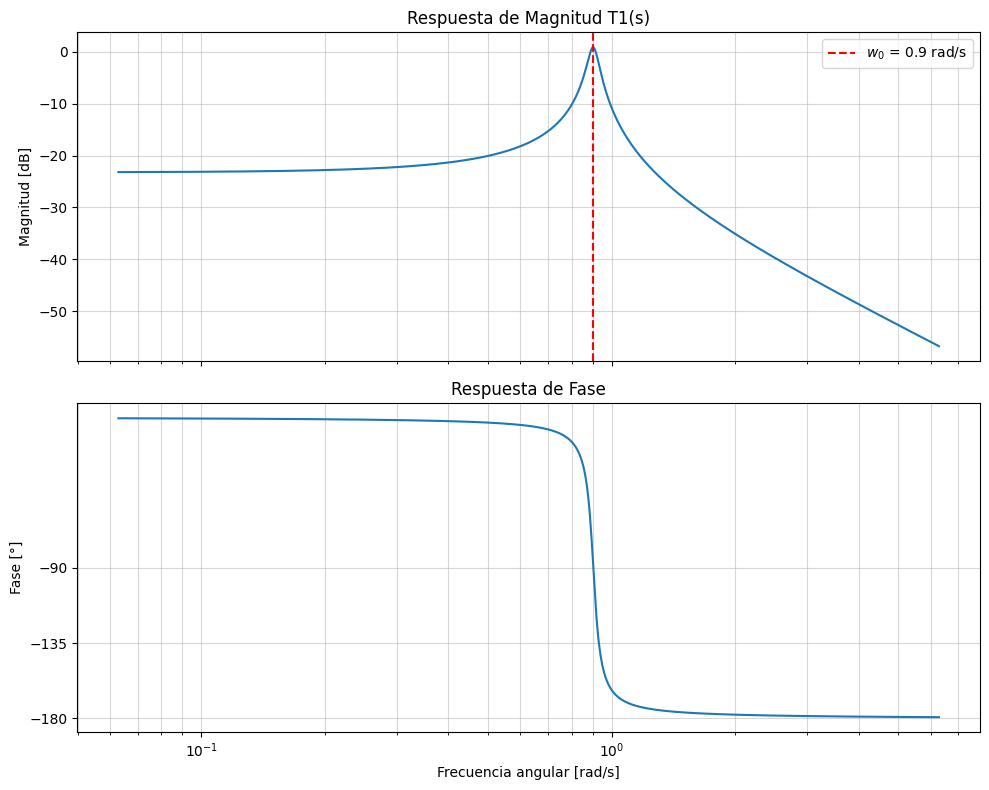

In [18]:
w, mag, phase = sig.bode(T1,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

attenuation_db = -mag

# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud T1(s)')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.axvline(0.9, color='red', linestyle='--', label=f'$w_0$ = {0.9} rad/s')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)
ax_mag.legend()

# Gráfico de Fase
ticks = np.arange(-630, -89, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

ax_phase.set_xlabel('Frecuencia angular [rad/s]')


plt.tight_layout()
plt.show()

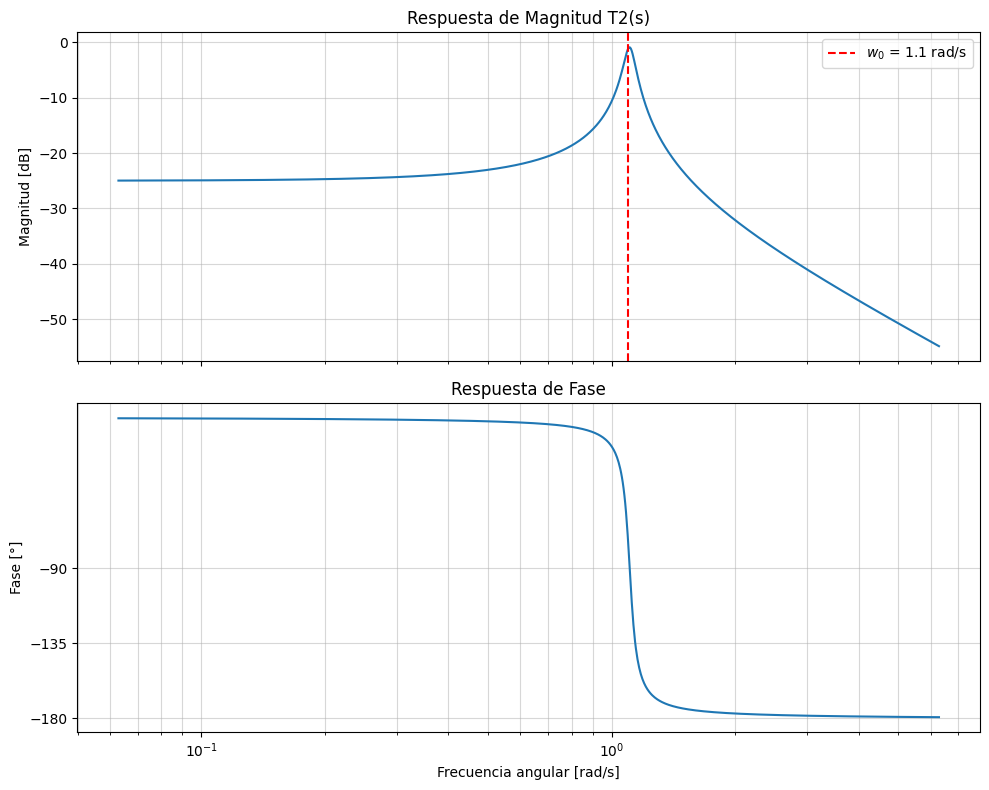

In [19]:
w, mag, phase = sig.bode(T2,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

attenuation_db = -mag

# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud T2(s)')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)
ax_mag.axvline(1.1, color='red', linestyle='--', label=f'$w_0$ = {1.1} rad/s')
ax_mag.legend()

# Gráfico de Fase
ticks = np.arange(-630, -89, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

ax_phase.set_xlabel('Frecuencia angular [rad/s]')


plt.tight_layout()
plt.show()

💡Es muy interesante notar el detalle de como los puntos de resonancia de T1 y T2 parecieran coincidir con los extremos de la banda de paso mientras que el pico de T0 corresponde al centro de la banda.

### Bonus 1
Ya teniendo la transferencia factorizada en SOS, tomo a cada uno de estos factores y los sintetizo con la siguiente red.

<center><img src="./src/img5_TS4.png"  width="800"></center>

Los valores de los componentes normalizados son:

- $C_0=C_1=C_2=1$

- $R_0=8$
- $L_0=1$

- $R_1=17,857$
- $L_1=1,506$

- $R_2=14,493$
- $L_2=0,665$

El siguiente paso es la desnormalización. Calculo la norma de frecuencia $\Omega_\omega$ para tener capacitores de **10nF**.

<center><img src="./src/img6_TS4.png"  width="800"></center>

Los valores de los componentes denormalizados son:

- $C_0=C_1=C_2=10nF$

- $R_0=5,787K\Omega$
- $L_0=5,234mHy$

- $R_1=12,918K\Omega$
- $L_1=7,882mHy$

- $R_2=10,485K\Omega$
- $L_2=3,48mHy$

En este momento me encontré con un inconveniente: la banda de paso del filtro se ve fuertemente atenuada.

Esto ocurre porque cada etapa atenúa a los picos de las demás, se puede ver claramente en la sumulación.

<center><img src="./src/img7_TS4.png"  width="1070"></center>
<center><img src="./src/img8_TS4.jpeg"  width="1070"></center>

La solución que encontré fue **agregar una entapa de amplificación**, con un *no inversor*, para suplir defecto.

### Bonus 2

Aplico el núclo de transformación *pasa altos* a la transferencia prototipo *pasa bajos*.

<center><img src="./src/img9_TS4.png"  width="800"></center>

Se llega a:

### $T[S)=T(s)|_{s=1/S} = \frac{0,876S²}{S²+0,548S+0,876} * \frac{1,597S}{S+1,597}$

### Conclusión

En esta tarea se diseñó un *filtro pasabanda* a partir de una *aproximación Chebyshev*, partiendo de las especificaciones de atenuación y selectividad impuestas por la plantilla. Mediante la normalización en frecuencia se obtuvo el *prototipo pasabajos* equivalente y, posteriormente, se aplicó la *transformación pasabanda* para obtener la función transferencia final.

A la hora de la implementación con redes pasivas me crucé con el problema de atenuación de la banda de paso pero este pudo ser resuelto aplicando conocimientos previos concatenado un *amplificador no inversor*. 